# H3 Altitude Layer Generation

Single source for building the 3D weather grid: ERA5 pressure levels mapped onto
H3 cells as altitude layers, then vertically densified by interpolation.

**Pipeline:** trajectories -> unique H3 cells -> geometric mapping to ERA5 grid
(largest-overlap winner) -> extract weather per (cell, level, time) -> interpolate
to a denser set of levels.

Reads NetCDF or GRIB (auto-detected by file content, not extension).

## 1. Imports
Imported libraries for this task.

In [20]:
from pathlib import Path
from collections import Counter
from datetime import datetime, timedelta, date
import re

import h3
import numpy as np
import pandas as pd
import polars as pl
import xarray as xr
from shapely.geometry import Polygon, box
from scipy import stats
import matplotlib.pyplot as plt

## 2. Configuration

In [21]:
PROJECT_ROOT = Path("/home/tolgaakcay/projects/AircraftTrajectoryPrediction_Thesis")

DATA_SOURCE = PROJECT_ROOT / "src" / "data" / "raw" #Raw Trajectory Data Directory 
WEATHER_DIR = PROJECT_ROOT / "src" / "data" / "weather" #Weather Directory to obtain weather data

AIRPORT = "LFBO"
START = "2024-10-1"
END = "2024-11-6"

H3_RESOLUTION = 5
GRID_STEP_DEG = 0.25

WEATHER_VARS = ["u", "v", "t", "z", "q", "w"]
N_TIMES = None

OUTPUT_LAYERS = WEATHER_DIR / "h3_weather_layers.parquet" 
OUTPUT_OVERLAP = WEATHER_DIR / "h3_era5_overlap_report.parquet" #Report file for statistics about the integration
OUTPUT_TRAJ_WEATHER = WEATHER_DIR / f"trajectory_weather_features_{START}_{END}.parquet"

## 3. Helpers: file format and name resolution

CDS is inconsistent about coordinate and variable naming, and a GRIB file may
carry a `.nc` extension, so format is detected from the file's magic bytes.

In [22]:
def detect_format(path):
    with open(path, "rb") as f:
        magic = f.read(4)
    if magic == b"GRIB":
        return "grib"
    return "netcdf"


def open_weather_file(path):
    fmt = detect_format(path)
    if fmt == "grib":
        ds = xr.open_dataset(path, engine="cfgrib")
    else:
        ds = xr.open_dataset(path)
    time_name = find_coord(ds, ["valid_time", "time"])
    return ds.sortby(time_name)


def find_coord(ds, candidates):
    for name in candidates:
        if name in ds.coords or name in ds.variables:
            return name
    raise KeyError(f"None of {candidates} found. Available: {list(ds.coords)}")


def find_vars(ds, wanted):
    long_names = {
        "u": "u_component_of_wind", "v": "v_component_of_wind",
        "t": "temperature", "z": "geopotential",
        "q": "specific_humidity", "w": "vertical_velocity",
    }
    present = {}
    for short in wanted:
        if short in ds.data_vars:
            present[short] = short
        elif long_names.get(short) in ds.data_vars:
            present[short] = long_names[short]
    return present


def list_weather_files_by_day(weather_dir, airport):
    """Change to OG Code - matches download_weather.py's partitioned layout
    (weather_dir/year=Y/month=M/day=D/era5_{airport}_{date}.{grib,nc}) instead of
    a flat directory of range-named files. The day comes from the year=/month=/day=
    partition folders themselves (the source of truth, same convention already used
    for the raw trajectory parquet elsewhere in this project), not re-parsed from
    the filename. Anything that doesn't match this exact structure - the cfgrib
    .idx sidecar, this notebook's own .parquet outputs - is ignored."""
    pattern = re.compile(rf"era5_{re.escape(airport)}_\d{{4}}-\d{{2}}-\d{{2}}\.(grib|nc)$")
    by_day = {}
    for p in sorted(Path(weather_dir).glob("year=*/month=*/day=*/*")):
        if not p.is_file():
            continue
        m = pattern.match(p.name)
        if not m:
            continue
        year_part, month_part, day_part, _ = p.relative_to(weather_dir).parts
        try:
            year, month, day_num = (int(part.split("=")[1]) for part in (year_part, month_part, day_part))
        except (IndexError, ValueError):
            continue
        day = date(year, month, day_num)
        by_day.setdefault(day, {})[m.group(1)] = p
    return by_day


def resolve_weather_file(files_by_day, day, prefer=("grib", "nc")):
    #Prefer .grib over .nc
    exts = files_by_day.get(day)
    if not exts:
        return None
    for ext in prefer:
        if ext in exts:
            return exts[ext]
    return None

def days_in_range(start, end):
    start_date = datetime.strptime(start, "%Y-%m-%d")
    end_date = datetime.strptime(end, "%Y-%m-%d")
    num_days = (end_date - start_date).days
    return [(start_date + timedelta(days=x)).date() for x in range(num_days)]

## 4. Load trajectories and derive unique H3 cells

Only cells the aircraft actually fly through are built, not the whole bounding box.
Uses the full trajectory history regardless of [START, END], so the mapping is the
same H3 cell set no matter which date range a given run processes.

In [23]:
def load_unique_h3_cells(data_source, airport, resolution):
    lf = pl.scan_parquet(
        source=str(Path(data_source) / "**" / "*.parquet"),
        hive_schema={
            "destination": pl.String, "year": pl.Int64,
            "month": pl.Int64, "day": pl.Int64,
        },
        hive_partitioning=True,
        cast_options=pl.ScanCastOptions(datetime_cast="nanosecond-downcast"),
    ).filter(pl.col("destination") == airport)

    pts = lf.select(
        pl.col("latitude").explode().alias("lat"),
        pl.col("longitude").explode().alias("lon"),
    ).collect()

    lats = pts.get_column("lat").to_numpy()
    lons = pts.get_column("lon").to_numpy()
    mask = ~(np.isnan(lats) | np.isnan(lons))
    lats, lons = lats[mask], lons[mask]

    cells = {h3.latlng_to_cell(la, lo, resolution) for la, lo in zip(lats, lons)}
    return sorted(cells), len(lats)


cells, n_points = load_unique_h3_cells(DATA_SOURCE, AIRPORT, H3_RESOLUTION)
print(f"Trajectory points (full history): {n_points:,}")
print(f"Unique H3 cells at resolution {H3_RESOLUTION}: {len(cells):,}")

Trajectory points (full history): 4,048,210
Unique H3 cells at resolution 5: 13,861


### 5. Altitude Analysis
This section analyses the input trajectory data for [START, END], and produces an altitude distribution graph based on the data.

Trajectory points with altitude (2024-10-1 -> 2024-11-6): 2,155,230
Range  : -2,202,952 to 210,247 ft
Mean   : 24,484 ft
Median : 28,975 ft
Std dev: 20,598 ft

Percentiles:
   1th:    1,450 ft
   5th:    3,075 ft
  10th:    5,200 ft
  25th:   14,925 ft
  50th:   28,975 ft
  75th:   35,000 ft
  90th:   38,000 ft
  95th:   39,000 ft
  99th:   41,000 ft

Densest 1,000 ft bands:
  35,000-36,000 ft:  7.50%
  33,000-34,000 ft:  5.66%
  34,000-35,000 ft:  5.10%
  39,000-40,000 ft:  5.09%
  37,000-38,000 ft:  5.06%
  29,000-30,000 ft:  4.13%
  31,000-32,000 ft:  3.69%
  38,000-39,000 ft:  3.33%


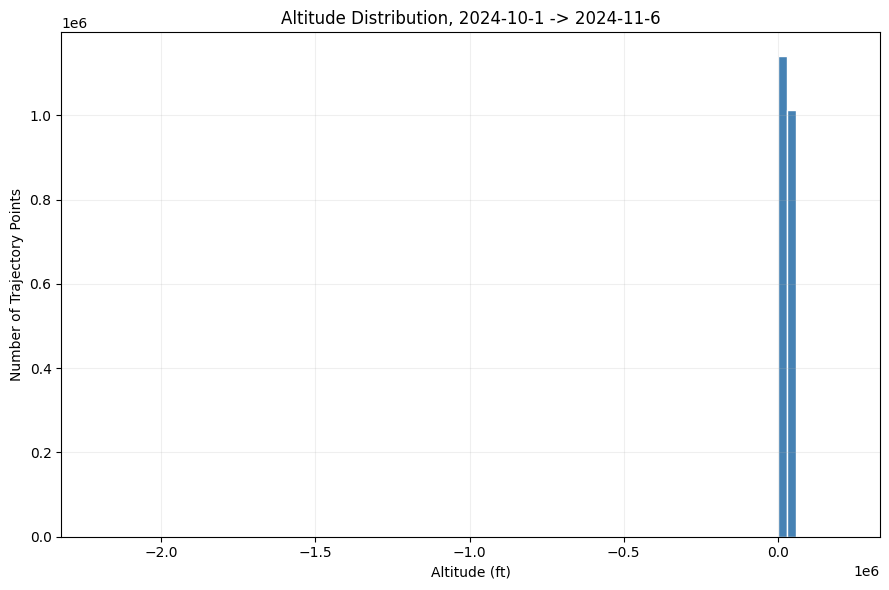

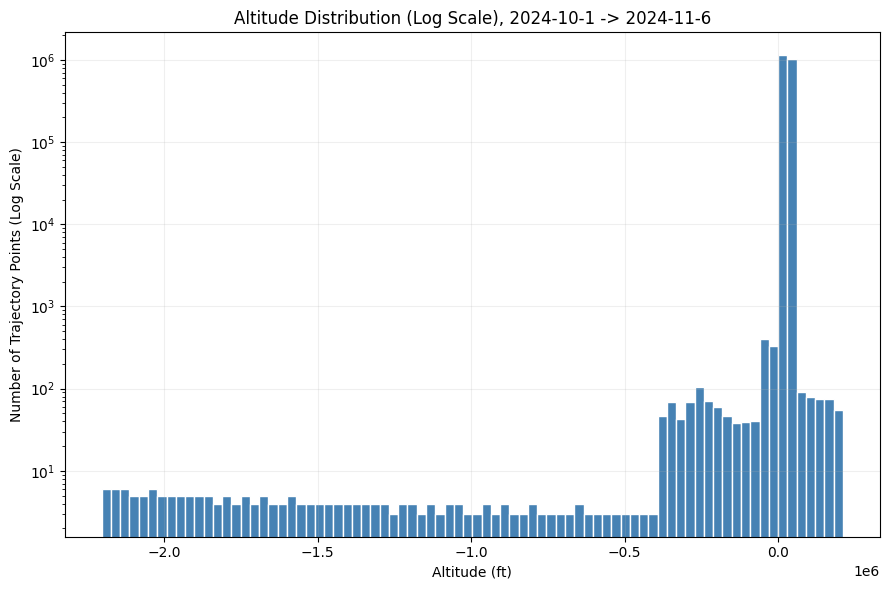

In [24]:
def load_altitudes(data_source, airport, start, end):
    #Change to OG Code - scoped to [start, end): this is a diagnostic of the currently-loaded
    #dataset, unlike section 4's H3 cells which intentionally stay full-history
    days = days_in_range(start, end)
    day_filter = [{"year": d.year, "month": d.month, "day": d.day} for d in days]
    lf = pl.scan_parquet(
        source=str(Path(data_source) / "**" / "*.parquet"),
        hive_schema={
            "destination": pl.String, "year": pl.Int64,
            "month": pl.Int64, "day": pl.Int64,
        },
        hive_partitioning=True,
        cast_options=pl.ScanCastOptions(datetime_cast="nanosecond-downcast"),
    ).filter(
        (pl.col("destination") == airport)
        & (pl.struct(["year", "month", "day"]).is_in(day_filter))
    )
    a = lf.select(pl.col("altitude").explode().alias("alt")).collect()
    a = a.get_column("alt").to_numpy()
    return a[~np.isnan(a)]


altitudes = load_altitudes(DATA_SOURCE, AIRPORT, START, END)

print(f"Trajectory points with altitude ({START} -> {END}): {len(altitudes):,}")
print(f"Range  : {altitudes.min():,.0f} to {altitudes.max():,.0f} ft")
print(f"Mean   : {altitudes.mean():,.0f} ft")
print(f"Median : {np.median(altitudes):,.0f} ft")
print(f"Std dev: {altitudes.std():,.0f} ft")

print("\nPercentiles:")
for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:
    print(f"  {p:>2}th: {np.percentile(altitudes, p):>8,.0f} ft")

DENSITY_BIN_FT = 1000
edges = np.arange(0, altitudes.max() + DENSITY_BIN_FT, DENSITY_BIN_FT)
counts, _ = np.histogram(altitudes, bins=edges)
altitude_density = pl.DataFrame({
    "alt_low_ft": edges[:-1].astype(int),
    "alt_high_ft": edges[1:].astype(int),
    "n_points": counts,
    "share_pct": counts / counts.sum() * 100,
})

print(f"\nDensest {DENSITY_BIN_FT:,} ft bands:")
for r in altitude_density.sort("share_pct", descending=True).head(8).iter_rows(named=True):
    print(f"  {r['alt_low_ft']:>6,}-{r['alt_high_ft']:<6,} ft: {r['share_pct']:5.2f}%")

altitude_density.sort('share_pct', descending=True).head(10)

#Change to OG Code - split into two separate figures instead of a subplot grid (one graph per figure)
fig, ax = plt.subplots(figsize=(9, 6))
ax.hist(altitudes, bins=80, color="steelblue", edgecolor="white")
ax.set_xlabel("Altitude (ft)")
ax.set_ylabel("Number of Trajectory Points")
ax.set_title(f"Altitude Distribution, {START} -> {END}")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 6))
ax.hist(altitudes, bins=80, color="steelblue", edgecolor="white")
ax.set_yscale("log")
ax.set_xlabel("Altitude (ft)")
ax.set_ylabel("Number of Trajectory Points (Log Scale)")
ax.set_title(f"Altitude Distribution (Log Scale), {START} -> {END}")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

### 5b. Pressure-altitude range distribution

The percentile/histogram view above shows the overall altitude spread but not how it
lines up with pressure levels. Here we  convert every
point to pressure directly and bin into fixed-width ranges, so the picture isn't tiedto any particular set of download levels. Nothing is dropped: a small number of points have a physically implausible altitude and are shown as an explicit "invalid" bucket rather than being silently excluded.

1967 of 2155230 points (0.0913%) have a physically implausible altitude and fall in the invalid bucket


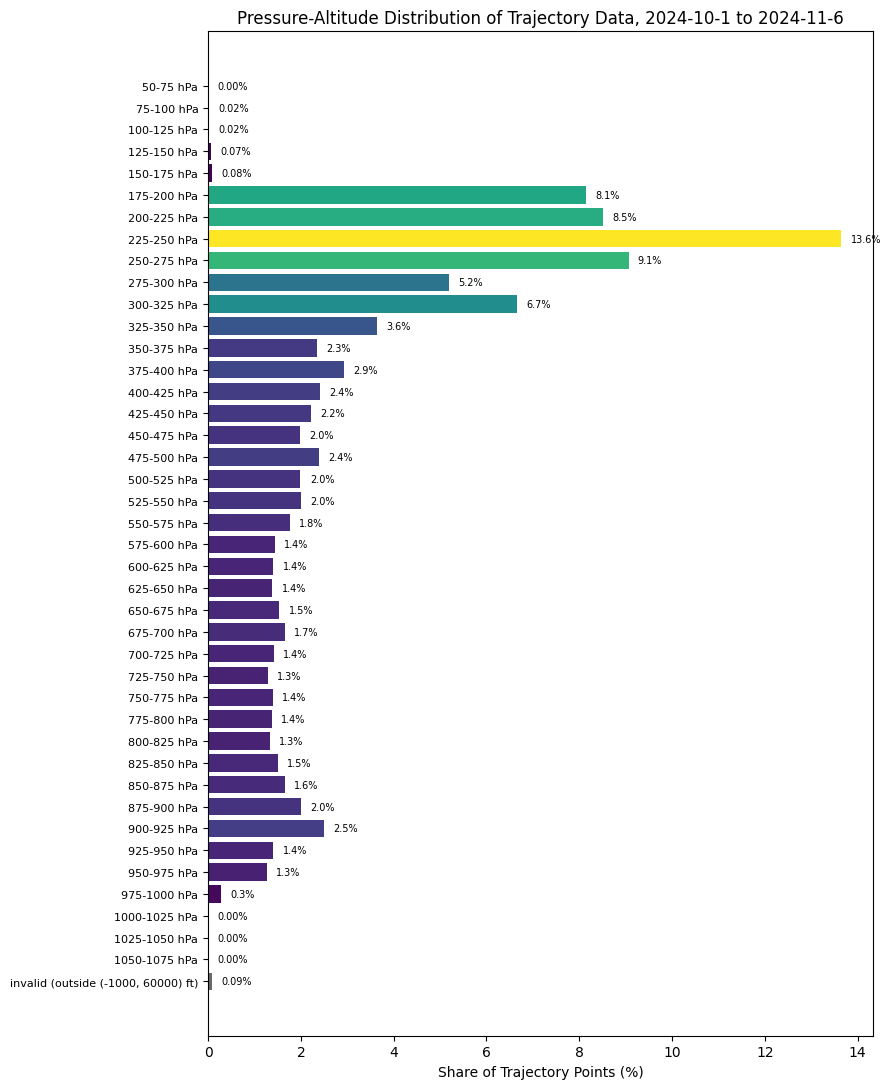

In [25]:
ALT_PLAUSIBLE_FT = (-1000, 60000)
PRESSURE_BIN_WIDTH_HPA = 25

plausible = (altitudes >= ALT_PLAUSIBLE_FT[0]) & (altitudes <= ALT_PLAUSIBLE_FT[1])
n_invalid = (~plausible).sum()
n_total = len(altitudes)

def altitude_ft_to_pressure_hpa(h_ft):
    h_m = np.asarray(h_ft) * 0.3048
    p_tropopause = 1013.25 * (1 - 0.0065 * 11000 / 288.15) ** 5.25588
    p_troposphere = 1013.25 * (1 - 0.0065 * h_m / 288.15) ** 5.25588
    p_stratosphere = p_tropopause * np.exp(-(h_m - 11000) / 6341.62)
    return np.where(h_m <= 11000, p_troposphere, p_stratosphere)

pressures = altitude_ft_to_pressure_hpa(altitudes[plausible])

lo = int(np.floor(pressures.min() / PRESSURE_BIN_WIDTH_HPA) * PRESSURE_BIN_WIDTH_HPA)
hi = int(np.ceil(pressures.max() / PRESSURE_BIN_WIDTH_HPA) * PRESSURE_BIN_WIDTH_HPA)
edges = np.arange(lo, hi + PRESSURE_BIN_WIDTH_HPA, PRESSURE_BIN_WIDTH_HPA)
counts, _ = np.histogram(pressures, bins=edges)

labels = [f"{edges[i]}-{edges[i+1]} hPa" for i in range(len(edges) - 1)]
share_pct = counts / n_total * 100  # share of the FULL dataset, invalid bucket included
labels.append(f"invalid (outside {ALT_PLAUSIBLE_FT} ft)")
share_pct = np.append(share_pct, n_invalid / n_total * 100)
print(f"{n_invalid} of {n_total} points ({share_pct[-1]:.4f}%) have a physically "
      f"implausible altitude and fall in the invalid bucket")

fig, ax = plt.subplots(figsize=(9, 11))
y = np.arange(len(labels))
colors = list(plt.cm.viridis(share_pct[:-1] / share_pct[:-1].max())) + ["dimgray"]
ax.barh(y, share_pct, color=colors)
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("Share of Trajectory Points (%)")
ax.set_title(f"Pressure-Altitude Distribution of Trajectory Data, {START} to {END}")  #Change to OG Code - was hardcoded to a fixed date and mislabeled as ERA5 data; this converts trajectory altitude via a standard-atmosphere formula, it is not ERA5 pressure readings
for yi, pct in zip(y, share_pct):
    if pct > 0:
        label = f"{pct:.2f}%" if pct < 0.1 else f"{pct:.1f}%"
        ax.text(pct + 0.2, yi, label, va="center", fontsize=7)
plt.tight_layout()
plt.show()

## 6. Resolve weather files for [START, END]

Weather is resolved per calendar day, preferring `.grib` (the format future downloads
will use) and falling back to `.nc` for any day that doesn't have a `.grib` file yet.
Both trajectory and weather coverage for the whole requested range are checked up
front - if either is missing for any day, this stops here with the exact list of
what's missing rather than silently running on a partial range.

In [26]:
requested_days = days_in_range(START, END)

files_by_day = list_weather_files_by_day(WEATHER_DIR, AIRPORT)
weather_for_day = {d: resolve_weather_file(files_by_day, d) for d in requested_days}
missing_weather = [d for d, f in weather_for_day.items() if f is None]

trajectory_days_present = set(
    pl.scan_parquet(
        source=str(DATA_SOURCE / "**" / "*.parquet"),
        hive_schema={"destination": pl.String, "year": pl.Int64, "month": pl.Int64, "day": pl.Int64},
        hive_partitioning=True,
    )
    .filter(pl.col("destination") == AIRPORT)
    .select("year", "month", "day")
    .unique()
    .collect()
    .with_columns(pl.date(pl.col("year"), pl.col("month"), pl.col("day")).alias("date"))
    ["date"]
    .to_list()
)
missing_trajectory = [d for d in requested_days if d not in trajectory_days_present]

if missing_weather or missing_trajectory:
    msg = [f"Requested range {START} -> {END} is not fully covered:"]
    if missing_weather:
        msg.append(f"  missing weather file for: {missing_weather}")
    if missing_trajectory:
        msg.append(f"  missing trajectory data for: {missing_trajectory}")
    raise ValueError("\n".join(msg))

print(f"{len(requested_days)} days requested, all covered by both trajectory and weather data:")
for d in requested_days:
    print(f"  {d}: {weather_for_day[d].name}")

ds = open_weather_file(weather_for_day[requested_days[0]])

lat_name = find_coord(ds, ["latitude", "lat"])
lon_name = find_coord(ds, ["longitude", "lon"])
time_name = find_coord(ds, ["valid_time", "time"])
level_name = find_coord(ds, ["pressure_level", "level", "isobaricInhPa"])
var_map = find_vars(ds, WEATHER_VARS)

era5_lats = ds[lat_name].values.astype(float)
era5_lons = ds[lon_name].values.astype(float)
levels = ds[level_name].values
times = pd.to_datetime(ds[time_name].values)
if N_TIMES is not None:
    times = times[:N_TIMES]

print(f"\nreference file (used to build the H3 <-> ERA5 mapping): {weather_for_day[requested_days[0]].name}")
print(f"variables: {list(var_map.keys())}")
print(f"levels:    {levels.astype(int).tolist()}")
print(f"times:     {len(times)}  ({times.min()} -> {times.max()})")
print(f"grid:      {len(era5_lats)} lat x {len(era5_lons)} lon")

36 days requested, all covered by both trajectory and weather data:
  2024-10-01: era5_LFBO_2024-10-01.grib
  2024-10-02: era5_LFBO_2024-10-02.grib
  2024-10-03: era5_LFBO_2024-10-03.grib
  2024-10-04: era5_LFBO_2024-10-04.grib
  2024-10-05: era5_LFBO_2024-10-05.grib
  2024-10-06: era5_LFBO_2024-10-06.grib
  2024-10-07: era5_LFBO_2024-10-07.grib
  2024-10-08: era5_LFBO_2024-10-08.grib
  2024-10-09: era5_LFBO_2024-10-09.grib
  2024-10-10: era5_LFBO_2024-10-10.grib
  2024-10-11: era5_LFBO_2024-10-11.grib
  2024-10-12: era5_LFBO_2024-10-12.grib
  2024-10-13: era5_LFBO_2024-10-13.grib
  2024-10-14: era5_LFBO_2024-10-14.grib
  2024-10-15: era5_LFBO_2024-10-15.grib
  2024-10-16: era5_LFBO_2024-10-16.grib
  2024-10-17: era5_LFBO_2024-10-17.grib
  2024-10-18: era5_LFBO_2024-10-18.grib
  2024-10-19: era5_LFBO_2024-10-19.grib
  2024-10-20: era5_LFBO_2024-10-20.grib
  2024-10-21: era5_LFBO_2024-10-21.grib
  2024-10-22: era5_LFBO_2024-10-22.grib
  2024-10-23: era5_LFBO_2024-10-23.grib
  2024-10-24

## 7. Geometry: H3 hexagons and ERA5 grid boxes

Longitude is scaled by cos (latitude) so the overlap areas are approximately
equal-area and the winner selection is not biased by meridian convergence.

In [27]:
def h3_cell_polygon(cell, lat_ref):
    coords = h3.cell_to_boundary(cell)
    scaled = [(lon * np.cos(np.radians(lat_ref)), lat) for lat, lon in coords]
    return Polygon(scaled)


def era5_box_polygon(lat, lon, step, lat_ref):
    half = step / 2.0
    w = (lon - half) * np.cos(np.radians(lat_ref))
    e = (lon + half) * np.cos(np.radians(lat_ref))
    return box(w, lat - half, e, lat + half)

## 8. Build the H3 -> ERA5 mapping (largest overlap wins)

Purely geometric, so it is computed once and reused for every level and time.

In [28]:
def build_mapping(cells, era5_lats, era5_lons, step):
    records = []
    for cell in cells:
        cell_lat, cell_lon = h3.cell_to_latlng(cell)
        poly = h3_cell_polygon(cell, cell_lat)
        cell_area = poly.area
        if cell_area <= 0:
            continue

        li = np.where(np.abs(era5_lats - cell_lat) <= step * 2)[0]
        oi = np.where(np.abs(era5_lons - cell_lon) <= step * 2)[0]

        overlaps = []
        for a in li:
            for b in oi:
                inter = poly.intersection(
                    era5_box_polygon(era5_lats[a], era5_lons[b], step, cell_lat)
                ).area
                if inter > 0:
                    overlaps.append((a, b, inter))
        if not overlaps:
            continue

        overlaps.sort(key=lambda t: t[2], reverse=True)
        wa, wb, warea = overlaps[0]
        records.append({
            "h3_cell": cell, "cell_lat": cell_lat, "cell_lon": cell_lon,
            "n_era5_cells": len(overlaps),
            "winner_lat_idx": int(wa), "winner_lon_idx": int(wb),
            "winner_lat": float(era5_lats[wa]), "winner_lon": float(era5_lons[wb]),
            "winner_share_pct": float(warea / cell_area * 100.0),
            "shares_pct": [float(a2 / cell_area * 100.0) for _, _, a2 in overlaps],
        })
    return records


print("Building geometric mapping...")
mapping = build_mapping(cells, era5_lats, era5_lons, GRID_STEP_DEG)
print(f"Mapped cells: {len(mapping):,}")

Building geometric mapping...
Mapped cells: 13,861


## 9. Mapping diagnostics

In [29]:
n_arr = np.array([m['n_era5_cells'] for m in mapping])
w = np.array([m['winner_share_pct'] for m in mapping])
cell_lat = np.array([m['cell_lat'] for m in mapping])
cell_lon = np.array([m['cell_lon'] for m in mapping])
n_cells_mapped = len(mapping)

print("=" * 66)
print("1. ERA5 CELLS OVERLAPPING EACH H3 CELL")
print("=" * 66)
counts = Counter(n_arr.tolist())
for k in sorted(counts):
    p = counts[k] / n_cells_mapped * 100
    print(f"  {k} cell(s): {counts[k]:>7,} ({p:5.2f}%)")
print(f"  mean {n_arr.mean():.2f} | median {np.median(n_arr):.0f} | max {n_arr.max()}")

print("\n" + "=" * 66)
print("2. WINNER COVERAGE (share of H3 cell held by the winning ERA5 cell)")
print("=" * 66)
print(f"  mean {w.mean():.1f}% | median {np.median(w):.1f}% | sd {w.std():.1f}")
print("  percentiles:")
for q in [1, 5, 25, 50, 75, 95, 99]:
    print(f"    {q:>2}th: {np.percentile(w, q):5.1f}%")
print("  cumulative:")
for thr in [50, 75, 90]:
    print(f"    winner >= {thr}%: {(w >= thr).mean() * 100:5.1f}% of cells")
print("\n  FRAGMENTATION (area assigned from non-winning cells):")
print(f"    mean {100 - w.mean():.1f}% | median {100 - np.median(w):.1f}% "
      f"| worst {100 - w.min():.1f}%")

print("\n" + "=" * 66)
print("3. GEOGRAPHIC DEPENDENCE")
print("=" * 66)
#Change to OG Code - band edges computed from the actual loaded cell_lat range instead of
#fixed absolute latitudes tuned to LFBO; adapts to whatever AIRPORT/date range is configured
print("  by latitude band:")
print(f"    {'band':>10} {'cells':>8} {'mean n':>8} {'mean winner%':>13}")
LAT_BAND_WIDTH_DEG = 5
lat_lo = int(np.floor(cell_lat.min() / LAT_BAND_WIDTH_DEG) * LAT_BAND_WIDTH_DEG)
lat_hi = int(np.ceil(cell_lat.max() / LAT_BAND_WIDTH_DEG) * LAT_BAND_WIDTH_DEG)
for lo in range(lat_lo, lat_hi, LAT_BAND_WIDTH_DEG):
    hi = lo + LAT_BAND_WIDTH_DEG
    m = (cell_lat >= lo) & (cell_lat < hi)
    if m.sum() > 10:
        print(f"    {lo:>3}-{hi:<3}N {m.sum():>8,} {n_arr[m].mean():>8.2f} "
              f"{w[m].mean():>12.1f}%")

r1, p1 = stats.pearsonr(cell_lat, n_arr)
r2, p2 = stats.pearsonr(cell_lat, w)
print(f"\n  corr(latitude, n_era5_cells)  r={r1:+.3f}  p={p1:.2e}")
print(f"  corr(latitude, winner_share)  r={r2:+.3f}  p={p2:.2e}")
print("  (ERA5 boxes narrow toward the poles, so more cells overlap at high latitude)")

#Change to OG Code - IQR-based outlier fencing on the loaded cell_lat/cell_lon themselves,
#instead of fixed absolute thresholds (100W, 60E, 25N) tuned to LFBO's route network; a
#different AIRPORT/hemisphere no longer silently gets the wrong "plausible" bounds
print("\n  geographic plausibility (catches junk trajectory coordinates):")

def iqr_outlier_bounds(x, k=3):
    q1, q3 = np.percentile(x, [25, 75])
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

lat_bounds = iqr_outlier_bounds(cell_lat)
lon_bounds = iqr_outlier_bounds(cell_lon)
for name, m in [
    (f"latitude outside [{lat_bounds[0]:.1f}, {lat_bounds[1]:.1f}]", (cell_lat < lat_bounds[0]) | (cell_lat > lat_bounds[1])),
    (f"longitude outside [{lon_bounds[0]:.1f}, {lon_bounds[1]:.1f}]", (cell_lon < lon_bounds[0]) | (cell_lon > lon_bounds[1])),
]:
    if m.sum():
        print(f"    {name}: {m.sum():>5} cells  <-- inspect these")
    else:
        print(f"    {name}: none")

overlap_df = pl.DataFrame([
    {k: m[k] for k in
     ["h3_cell", "cell_lat", "cell_lon", "n_era5_cells",
      "winner_lat", "winner_lon", "winner_share_pct", "shares_pct"]}
    for m in mapping
])
OUTPUT_OVERLAP.parent.mkdir(parents=True, exist_ok=True)
overlap_df.write_parquet(OUTPUT_OVERLAP)
print(f"\nSaved overlap report -> {OUTPUT_OVERLAP}")

1. ERA5 CELLS OVERLAPPING EACH H3 CELL
  1 cell(s):     193 ( 1.39%)
  2 cell(s):   4,468 (32.23%)
  3 cell(s):   2,328 (16.80%)
  4 cell(s):   6,749 (48.69%)
  5 cell(s):      90 ( 0.65%)
  6 cell(s):      33 ( 0.24%)
  mean 3.16 | median 3 | max 6

2. WINNER COVERAGE (share of H3 cell held by the winning ERA5 cell)
  mean 68.4% | median 67.3% | sd 18.7
  percentiles:
     1th:  30.9%
     5th:  38.3%
    25th:  53.8%
    50th:  67.3%
    75th:  84.2%
    95th:  98.5%
    99th: 100.0%
  cumulative:
    winner >= 50%:  82.7% of cells
    winner >= 75%:  38.2% of cells
    winner >= 90%:  17.1% of cells

  FRAGMENTATION (area assigned from non-winning cells):
    mean 31.6% | median 32.7% | worst 74.4%

3. GEOGRAPHIC DEPENDENCE
  by latitude band:
          band    cells   mean n  mean winner%
     30-35 N       26     3.08         68.8%
     35-40 N    1,291     3.04         69.9%
     40-45 N    3,041     3.07         69.4%
     45-50 N    6,835     3.18         68.3%
     50-55 N    

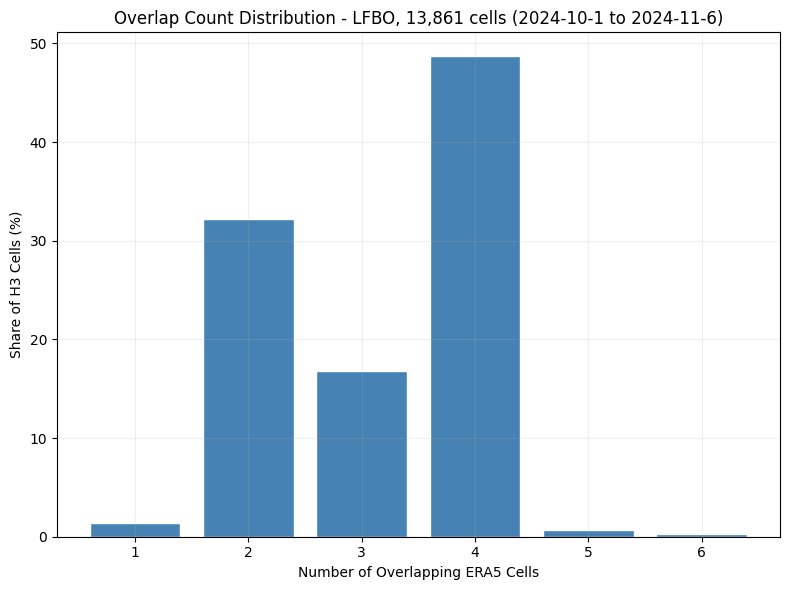

In [40]:
fig, ax = plt.subplots(figsize=(8, 6))
vals, cnts = np.unique(n_arr, return_counts=True)
ax.bar(vals, cnts / cnts.sum() * 100, color="steelblue", edgecolor="white")
ax.set_xlabel("Number of Overlapping ERA5 Cells")
ax.set_ylabel("Share of H3 Cells (%)")
ax.set_title(f"Overlap Count Distribution - {AIRPORT}, {n_cells_mapped:,} cells ({START} to {END})") 
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

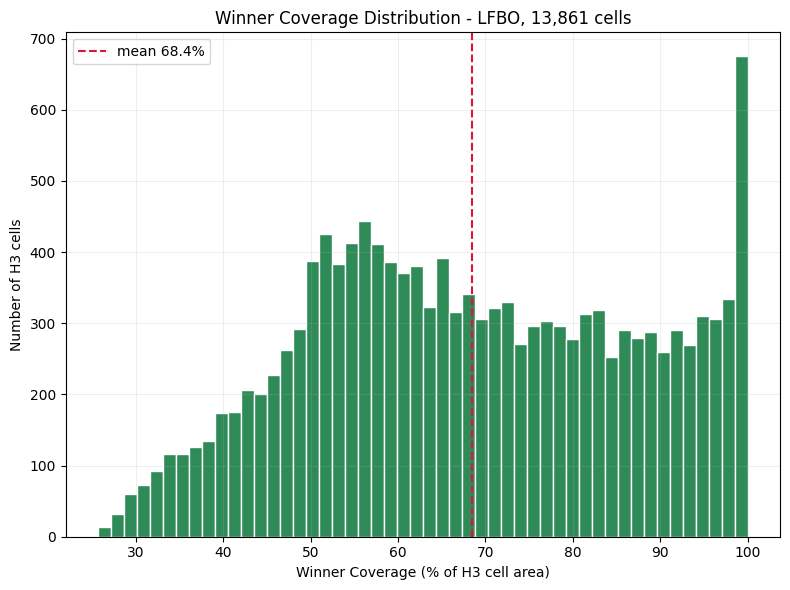

In [41]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(w, bins=50, color="seagreen", edgecolor="white")
ax.axvline(w.mean(), color="crimson", linestyle="--", label=f"mean {w.mean():.1f}%")
ax.set_xlabel("Winner Coverage (% of H3 cell area)")
ax.set_ylabel("Number of H3 cells")
ax.set_title(f"Winner Coverage Distribution - {AIRPORT}, {n_cells_mapped:,} cells")  #Change to OG Code - same as above
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## 10. Extract weather per (H3 cell, pressure level, time)

Pointwise `isel` pulls only the winning grid points, so the full lat/lon grid is
never materialised in memory. Wrapped as a function so section 14 can call it again
for every other day in the range.

In [32]:
def extract_layers(ds, var_map, mapping, levels, times, lat_name, lon_name, time_name):
    lat_idx = np.array([m['winner_lat_idx'] for m in mapping])
    lon_idx = np.array([m['winner_lon_idx'] for m in mapping])
    cell_ids = [m['h3_cell'] for m in mapping]

    cell_lat_sel = xr.DataArray(lat_idx, dims="cell")
    cell_lon_sel = xr.DataArray(lon_idx, dims="cell")

    frames = []
    for var_short, var_name in var_map.items():
        picked = (
            ds[var_name]
            .sel({time_name: times})
            .isel({lat_name: cell_lat_sel, lon_name: cell_lon_sel})
            .values
        )
        frames.append((var_short, picked))
        print(f"  extracted {var_short}: {picked.shape}")

    n_cells, n_lev, n_t = len(cell_ids), len(levels), len(times)
    out = {
        "h3_cell": np.tile(np.repeat(cell_ids, n_lev), n_t),
        "pressure_level": np.tile(np.tile(levels, n_cells), n_t),
        "valid_time": np.repeat(times.values, n_cells * n_lev),
    }
    for var_short, picked in frames:
        out[var_short] = picked.transpose(0, 2, 1).reshape(-1)
    return pl.DataFrame(out)


layers_df = extract_layers(ds, var_map, mapping, levels, times, lat_name, lon_name, time_name)
layers_df.write_parquet(OUTPUT_LAYERS)
print(f"\nRows: {layers_df.height:,} = {len(mapping):,} cells x {len(levels)} levels x {len(times)} times")
print(f"Saved -> {OUTPUT_LAYERS}")
layers_df.head(5)

  extracted u: (24, 25, 13861)
  extracted v: (24, 25, 13861)
  extracted t: (24, 25, 13861)
  extracted z: (24, 25, 13861)
  extracted q: (24, 25, 13861)
  extracted w: (24, 25, 13861)

Rows: 8,316,600 = 13,861 cells x 25 levels x 24 times
Saved -> /home/tolgaakcay/projects/AircraftTrajectoryPrediction_Thesis/src/data/weather/h3_weather_layers.parquet


h3_cell,pressure_level,valid_time,u,v,t,z,q,w
str,f64,datetime[ns],f32,f32,f32,f32,f32,f32
"""850e4123fffffff""",1000.0,2024-10-01 00:00:00,-1.676819,0.017349,286.044556,2022.339844,0.005112,-0.013468
"""850e4123fffffff""",975.0,2024-10-01 00:00:00,-1.680191,0.081863,284.673828,4095.962402,0.005112,-0.014332
"""850e4123fffffff""",950.0,2024-10-01 00:00:00,-3.450531,0.440689,283.017883,6214.618164,0.004679,0.005723
"""850e4123fffffff""",925.0,2024-10-01 00:00:00,-5.447769,1.304611,281.587891,8382.535156,0.004235,0.034376
"""850e4123fffffff""",900.0,2024-10-01 00:00:00,-5.32692,1.458603,279.789978,10595.826172,0.004188,0.049908


## 11. Geopotential to geometric height

`layers_df` already holds `z` per (H3 cell, pressure level, hour) from section 10 -
nothing new to build there. This step turns that geopotential into a true height in
metres above the WGS84 ellipsoid, the same frame `gps_altitude_m` lives in, so the two
are directly comparable. Wrapped as a function so section 14 can call it again for
every other day, since each day can have a different number of pressure levels
(e.g. 9 for the older .nc downloads vs 25 for .grib).

In [33]:
WGS84_POLAR_RADIUS_M = 6_356_766.0

def geopotential_to_profiles(layers_df, weather_vars):
    height_geopotential_m = pl.col("z") / 9.80665
    layers_h = (
        layers_df
        .with_columns(
            (WGS84_POLAR_RADIUS_M * height_geopotential_m
             / (WGS84_POLAR_RADIUS_M - height_geopotential_m)).alias("height_m")
        )
        .sort(["h3_cell", "valid_time", "height_m"])
    )
    n_levels = layers_h["pressure_level"].n_unique()
    n_profiles = layers_h.height // n_levels
    profile_cells = layers_h["h3_cell"].to_numpy()[::n_levels]
    profile_times = layers_h["valid_time"].to_numpy()[::n_levels]
    profile_height = layers_h["height_m"].to_numpy().reshape(n_profiles, n_levels)
    profile_vars = {v: layers_h[v].to_numpy().reshape(n_profiles, n_levels) for v in weather_vars}
    n_non_monotonic = np.sum(np.any(np.diff(profile_height, axis=1) <= 0, axis=1))
    return layers_h, n_levels, n_profiles, profile_cells, profile_times, profile_height, profile_vars, n_non_monotonic


(layers_h, n_levels, n_profiles, profile_cells, profile_times,
 profile_height, profile_vars, n_non_monotonic) = geopotential_to_profiles(layers_df, WEATHER_VARS)

print(f"{n_profiles:,} profiles ({n_levels} levels each)")
print(f"non-monotonic profiles (height should strictly increase up the stack): {n_non_monotonic}")

332,664 profiles (25 levels each)
non-monotonic profiles (height should strictly increase up the stack): 0


## 12. Load trajectory points for the whole date range

A trajectory point knows its H3 cell, its time, and its altitude in metres. This loads
every point across [START, END] once - h3_cell, gps_altitude_m and the nearest ERA5
hour are the same regardless of which day's weather file will be matched to it, so
there is no need to redo this per day. Section 14 filters this down to each day's
exact time window as it loops.

In [34]:
def load_all_trajectory_points(data_source, airport, h3_resolution, start, end):
    days = days_in_range(start, end)
    day_filter = [{"year": d.year, "month": d.month, "day": d.day} for d in days]
    lf = pl.scan_parquet(
        source=str(Path(data_source) / "**" / "*.parquet"),
        hive_schema={
            "destination": pl.String, "year": pl.Int64,
            "month": pl.Int64, "day": pl.Int64,
        },
        hive_partitioning=True,
        cast_options=pl.ScanCastOptions(datetime_cast="nanosecond-downcast"),
    ).filter(
        (pl.col("destination") == airport)
        & (pl.struct(["year", "month", "day"]).is_in(day_filter))
    )

    points = (
        lf.select("flight_id", "timestamp", "latitude", "longitude", "gps_altitude")
        .explode(["timestamp", "latitude", "longitude", "gps_altitude"])
        .collect()
    )
    n_no_altitude = points["gps_altitude"].is_null().sum()
    points = points.filter(
        pl.col("gps_altitude").is_not_null()
        & pl.col("latitude").is_not_null()
        & pl.col("longitude").is_not_null()
    )
    points = points.with_columns(
        (pl.col("gps_altitude") * 0.3048).alias("gps_altitude_m"),
        pl.col("timestamp").dt.round("1h").cast(pl.Datetime("ns")).alias("valid_hour"),
        pl.struct(["latitude", "longitude"]).map_elements(
            lambda r: h3.latlng_to_cell(r["latitude"], r["longitude"], h3_resolution),
            return_dtype=pl.String,
        ).alias("h3_cell"),
    )
    return points, n_no_altitude


all_points, n_no_altitude = load_all_trajectory_points(DATA_SOURCE, AIRPORT, H3_RESOLUTION, START, END)
print(f"{n_no_altitude:,} points have no gps_altitude and are dropped")
print(f"{all_points.height:,} trajectory points loaded for {START} -> {END}")

0 points have no gps_altitude and are dropped
2,155,230 trajectory points loaded for 2024-10-1 -> 2024-11-6


## 13. Bracket and interpolate

Within each point's local profile, find the two layers it sits between by height -
the bracketing layers differ point to point because the local heights differ, which is
the whole reason to use per-profile geopotential instead of a fixed table. Then blend
each weather variable by how far up between them the aircraft sits: 88% of the way up
means 88% of the upper layer plus 12% of the lower. Wrapped as a function; previewed
here on just the reference day before section 14 runs it for every day.

In [35]:
def bracket_interpolate(target_height_m, profile_idx, profile_height, profile_vars, weather_vars, n_levels):
    point_profile_heights = profile_height[profile_idx]

    n_levels_below = np.sum(target_height_m[:, None] >= point_profile_heights, axis=1) - 1
    n_clipped_below = np.sum(n_levels_below < 0)
    n_clipped_above = np.sum(n_levels_below >= n_levels - 1)
    lower_idx = np.clip(n_levels_below, 0, n_levels - 2)
    upper_idx = lower_idx + 1

    row = np.arange(len(profile_idx))
    height_lo = point_profile_heights[row, lower_idx]
    height_hi = point_profile_heights[row, upper_idx]
    frac = np.clip((target_height_m - height_lo) / (height_hi - height_lo), 0.0, 1.0)

    interpolated = {}
    for v in weather_vars:
        values = profile_vars[v][profile_idx]
        v_lo = values[row, lower_idx]
        v_hi = values[row, upper_idx]
        interpolated[v] = v_lo + frac * (v_hi - v_lo)
    return interpolated, frac, n_clipped_below, n_clipped_above


profile_index = pl.DataFrame({
    "h3_cell": profile_cells, "valid_time": profile_times, "profile_idx": np.arange(n_profiles),
})
weather_lo, weather_hi = layers_h["valid_time"].min(), layers_h["valid_time"].max()
preview_points = (
    all_points
    .filter((pl.col("valid_hour") >= weather_lo) & (pl.col("valid_hour") <= weather_hi))
    .join(profile_index, left_on=["h3_cell", "valid_hour"], right_on=["h3_cell", "valid_time"], how="left")
)
n_unmatched = preview_points["profile_idx"].is_null().sum()
preview_points = preview_points.filter(pl.col("profile_idx").is_not_null())

_, preview_frac, n_clip_below, n_clip_above = bracket_interpolate(
    preview_points["gps_altitude_m"].to_numpy(),
    preview_points["profile_idx"].to_numpy().astype(int),
    profile_height, profile_vars, WEATHER_VARS, n_levels,
)
print(f"preview day ({weather_lo.date()}): {preview_points.height:,} points matched, {n_unmatched:,} unmatched")
print(f"{n_clip_below:,} points below their profile's lowest level (clipped to the bottom layer)")
print(f"{n_clip_above:,} points above their profile's highest level (clipped to the top layer)")

preview day (2024-10-01): 66,999 points matched, 0 unmatched
0 points below their profile's lowest level (clipped to the bottom layer)
0 points above their profile's highest level (clipped to the top layer)


## 14. Process every day and build the combined dataset

Loops sections 10-13 over every day in [START, END], reusing the H3 <-> ERA5 mapping
built once in section 8 (it only depends on H3 cells and the ERA5 grid, not on which
day's data is loaded). Before reusing it for a given day, the grid is checked against
the reference day's grid - the mapping's winner_lat_idx/winner_lon_idx indices are
only valid if that still matches. Pressure levels are allowed to differ from day to
day (older .nc downloads have 9, newer .grib ones have 25); the bracketing math
doesn't assume a fixed level count. Each day's matched, interpolated points are
concatenated into one dataset spanning the whole range, tagged with which weather
file produced them.

In [36]:
all_days_results = []

for day in requested_days:
    weather_path = weather_for_day[day]

    if day == requested_days[0]:
        ds_day, lat_name_d, lon_name_d, time_name_d = ds, lat_name, lon_name, time_name
        var_map_d, levels_d, times_d = var_map, levels, times
    else:
        ds_day = open_weather_file(weather_path)
        lat_name_d = find_coord(ds_day, ["latitude", "lat"])
        lon_name_d = find_coord(ds_day, ["longitude", "lon"])
        time_name_d = find_coord(ds_day, ["valid_time", "time"])
        var_map_d = find_vars(ds_day, WEATHER_VARS)

        era5_lats_d = ds_day[lat_name_d].values.astype(float)
        era5_lons_d = ds_day[lon_name_d].values.astype(float)
        if (era5_lats_d.shape != era5_lats.shape or era5_lons_d.shape != era5_lons.shape
                or not np.allclose(era5_lats_d, era5_lats) or not np.allclose(era5_lons_d, era5_lons)):
            raise ValueError(
                f"{weather_path.name} has a different ERA5 grid than the reference file "
                f"({weather_for_day[requested_days[0]].name}); the H3 mapping isn't valid for it."
            )

        level_name_d = find_coord(ds_day, ["pressure_level", "level", "isobaricInhPa"])
        levels_d = ds_day[level_name_d].values
        times_d = pd.to_datetime(ds_day[time_name_d].values)
        if N_TIMES is not None:
            times_d = times_d[:N_TIMES]

    layers_df_d = extract_layers(ds_day, var_map_d, mapping, levels_d, times_d, lat_name_d, lon_name_d, time_name_d)
    (layers_h_d, n_levels_d, n_profiles_d, profile_cells_d, profile_times_d,
     profile_height_d, profile_vars_d, n_non_monotonic_d) = geopotential_to_profiles(layers_df_d, WEATHER_VARS)

    profile_index_d = pl.DataFrame({
        "h3_cell": profile_cells_d, "valid_time": profile_times_d,
        "profile_idx": np.arange(n_profiles_d),
    })
    weather_lo_d, weather_hi_d = layers_h_d["valid_time"].min(), layers_h_d["valid_time"].max()
    points_d = (
        all_points
        .filter((pl.col("valid_hour") >= weather_lo_d) & (pl.col("valid_hour") <= weather_hi_d))
        .join(profile_index_d, left_on=["h3_cell", "valid_hour"], right_on=["h3_cell", "valid_time"], how="left")
    )
    n_unmatched_d = points_d["profile_idx"].is_null().sum()
    points_d = points_d.filter(pl.col("profile_idx").is_not_null())

    interpolated_d, frac_d, n_clip_below_d, n_clip_above_d = bracket_interpolate(
        points_d["gps_altitude_m"].to_numpy(),
        points_d["profile_idx"].to_numpy().astype(int),
        profile_height_d, profile_vars_d, WEATHER_VARS, n_levels_d,
    )

    result_d = (
        points_d
        .select("flight_id", "timestamp", "h3_cell", "gps_altitude_m")
        .with_columns([pl.Series(v, interpolated_d[v]) for v in WEATHER_VARS])
        .with_columns(
            pl.Series("interp_frac", frac_d),
            pl.lit(day).alias("weather_date"),
            pl.lit(weather_path.name).alias("weather_source"),
        )
    )
    all_days_results.append(result_d)
    print(f"{day}  ({weather_path.name}, {n_levels_d} levels): "
          f"{result_d.height:,} matched, {n_unmatched_d:,} unmatched, "
          f"{n_non_monotonic_d} non-monotonic profiles, "
          f"{n_clip_below_d:,}/{n_clip_above_d:,} clipped below/above")

result = pl.concat(all_days_results)
result.write_parquet(OUTPUT_TRAJ_WEATHER)
print(f"\nTotal rows: {result.height:,} across {len(requested_days)} days")
print(f"Saved -> {OUTPUT_TRAJ_WEATHER}")
result.head(5)

  extracted u: (24, 25, 13861)
  extracted v: (24, 25, 13861)
  extracted t: (24, 25, 13861)
  extracted z: (24, 25, 13861)
  extracted q: (24, 25, 13861)
  extracted w: (24, 25, 13861)
2024-10-01  (era5_LFBO_2024-10-01.grib, 25 levels): 66,999 matched, 0 unmatched, 0 non-monotonic profiles, 0/0 clipped below/above
  extracted u: (24, 25, 13861)
  extracted v: (24, 25, 13861)
  extracted t: (24, 25, 13861)
  extracted z: (24, 25, 13861)
  extracted q: (24, 25, 13861)
  extracted w: (24, 25, 13861)
2024-10-02  (era5_LFBO_2024-10-02.grib, 25 levels): 71,813 matched, 0 unmatched, 0 non-monotonic profiles, 0/946 clipped below/above
  extracted u: (24, 25, 13861)
  extracted v: (24, 25, 13861)
  extracted t: (24, 25, 13861)
  extracted z: (24, 25, 13861)
  extracted q: (24, 25, 13861)
  extracted w: (24, 25, 13861)
2024-10-03  (era5_LFBO_2024-10-03.grib, 25 levels): 68,685 matched, 0 unmatched, 0 non-monotonic profiles, 0/0 clipped below/above
  extracted u: (24, 25, 13861)
  extracted v: (

flight_id,timestamp,h3_cell,gps_altitude_m,u,v,t,z,q,w,interp_frac,weather_date,weather_source
str,datetime[μs],str,f64,f64,f64,f64,f64,f64,f64,f64,date,str
"""AFR12LW_048_2024_10_1""",2024-10-01 14:32:18,"""851fb46ffffffff""",632.46,4.696748,0.149409,284.490615,6201.678045,0.006535,-0.068722,0.567655,2024-10-01,"""era5_LFBO_2024-10-01.grib"""
"""AFR12LW_048_2024_10_1""",2024-10-01 14:32:23,"""851fb46ffffffff""",716.28,4.846966,0.047929,283.684159,7023.511997,0.006508,-0.080817,0.94329,2024-10-01,"""era5_LFBO_2024-10-01.grib"""
"""AFR12LW_048_2024_10_1""",2024-10-01 14:32:28,"""851fb46ffffffff""",784.86,4.935193,-0.040643,283.02577,7695.882694,0.006491,-0.085662,0.245856,2024-10-01,"""era5_LFBO_2024-10-01.grib"""
"""AFR12LW_048_2024_10_1""",2024-10-01 14:32:33,"""851fb46ffffffff""",853.44,5.015574,-0.130468,282.367706,8368.244589,0.006475,-0.089365,0.547341,2024-10-01,"""era5_LFBO_2024-10-01.grib"""
"""AFR12LW_048_2024_10_1""",2024-10-01 14:32:38,"""851fb46ffffffff""",937.26,5.113818,-0.240255,281.563406,9190.020239,0.006456,-0.09389,0.915823,2024-10-01,"""era5_LFBO_2024-10-01.grib"""


## 15. Sanity check: is the height conversion physical?

Height should increase and wind should generally strengthen going up the stack;
temperature should decrease. Checked directly on `layers_h`, the same per-profile
grid section 13 brackets against.

shape: (25, 4)
┌────────────────┬───────────┬───────────┬────────────┐
│ pressure_level ┆ height_ft ┆ wind_ms   ┆ temp_C     │
│ ---            ┆ ---       ┆ ---       ┆ ---        │
│ f64            ┆ f32       ┆ f32       ┆ f32        │
╞════════════════╪═══════════╪═══════════╪════════════╡
│ 150.0          ┆ 45625.0   ┆ 19.9      ┆ -55.900002 │
│ 175.0          ┆ 42387.0   ┆ 22.200001 ┆ -55.0      │
│ 200.0          ┆ 39576.0   ┆ 24.0      ┆ -54.5      │
│ 225.0          ┆ 37083.0   ┆ 24.799999 ┆ -52.299999 │
│ 250.0          ┆ 34823.0   ┆ 24.5      ┆ -48.700001 │
│ …              ┆ …         ┆ …         ┆ …          │
│ 900.0          ┆ 3273.0    ┆ 8.9       ┆ 10.4       │
│ 925.0          ┆ 2522.0    ┆ 8.8       ┆ 11.6       │
│ 950.0          ┆ 1788.0    ┆ 8.5       ┆ 12.9       │
│ 975.0          ┆ 1070.0    ┆ 7.8       ┆ 14.3       │
│ 1000.0         ┆ 368.0     ┆ 6.3       ┆ 15.9       │
└────────────────┴───────────┴───────────┴────────────┘


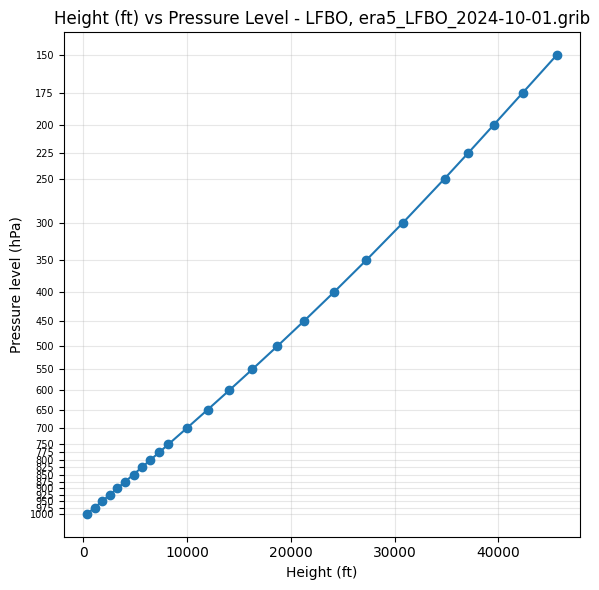

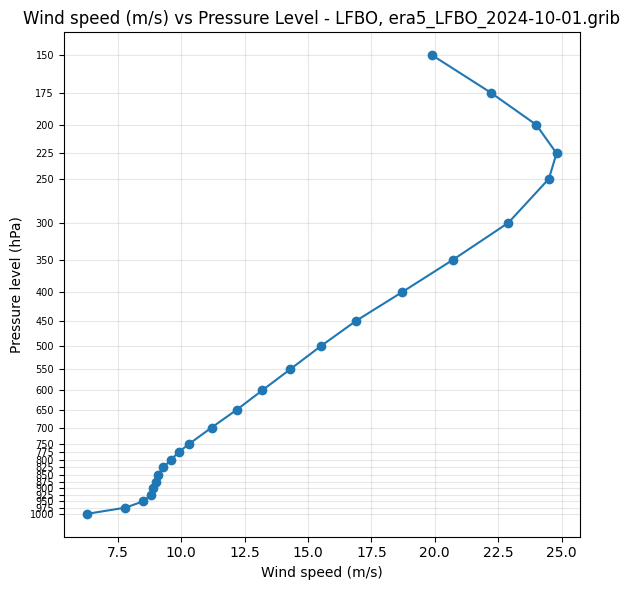

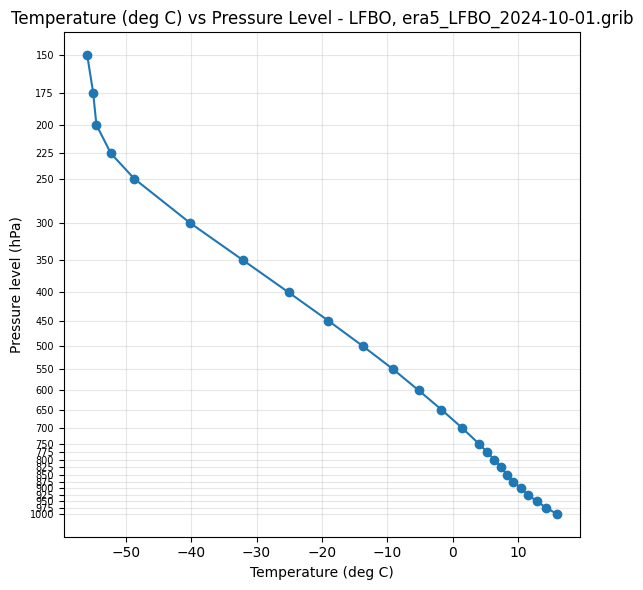

In [39]:
chk = (layers_h
       .with_columns((pl.col("height_m") * 3.28084).alias("height_ft"),
                     (pl.col("u")**2 + pl.col("v")**2).sqrt().alias("wind_ms"),
                     (pl.col("t") - 273.15).alias("temp_C"))
       .group_by("pressure_level")
       .agg(pl.col("height_ft").mean().round(0),
            pl.col("wind_ms").mean().round(1),
            pl.col("temp_C").mean().round(1))
       .sort("pressure_level"))
print(chk)

#Change to OG Code - split into three separate figures instead of a subplot grid (one graph per
#figure), and titled with the actual reference day/file instead of no title at all, so it's visible
#which loaded dataset each plot reflects
reference_label = f"{AIRPORT}, {weather_for_day[requested_days[0]].name}"
lv = chk["pressure_level"].to_numpy()
for col, lab in [("height_ft", "Height (ft)"), ("wind_ms", "Wind speed (m/s)"), ("temp_C", "Temperature (deg C)")]:
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot(chk[col].to_numpy(), lv, "o-")
    ax.invert_yaxis()
    ax.set_yscale("log")
    ax.set_yticks(lv)
    ax.set_yticklabels([f"{int(p)}" for p in lv], fontsize=7)
    ax.set_xlabel(lab)
    ax.set_ylabel("Pressure level (hPa)")
    ax.set_title(f"{lab} vs Pressure Level - {reference_label}")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()